# TF-IDF + Logistic Regression for Multi-label Aspect Detection

Notebook này xây dựng model **TF-IDF + Logistic Regression** cho bài toán phân loại đa nhãn các khía cạnh trong review nhà hàng.

Pipeline chính:

`review_cleaned -> TF-IDF Vectorizer -> One-vs-Rest Logistic Regression -> Threshold -> Predicted aspects`

In [2]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("seaborn is not installed. Confusion matrices will use matplotlib fallback.")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    hamming_loss,
    multilabel_confusion_matrix
)

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 200)

RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


seaborn is not installed. Confusion matrices will use matplotlib fallback.


## 1. Load data

File dữ liệu đã xử lý được đọc từ `Data/Restaurant_ABSA_processed.csv`.

In [3]:
DATA_PATH = "Data/Restaurant_ABSA_processed.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Cannot find {DATA_PATH}. Please make sure the notebook is run from the project root folder."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())

Dataset shape: (800, 7)


,review_en,review_cleaned,food,price,service,ambiance,miscellaneous
0,The food was very tasty but the price was high,food tasty price high,1,1,0,0,0
1,Although the food was good but the ambience was bad.,although food good ambience bad,1,0,0,1,0
2,Food always tastes fresh and served promptly.,food always taste fresh served promptly,1,0,1,0,0
3,Very good price and very good service.,good price good service,0,1,1,0,0
4,"It's a pretty relaxing place, now the food is good.",pretty relaxing place food good,1,0,0,1,0


<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   review_en       800 non-null    str  
 1   review_cleaned  800 non-null    str  
 2   food            800 non-null    int64
 3   price           800 non-null    int64
 4   service         800 non-null    int64
 5   ambiance        800 non-null    int64
 6   miscellaneous   800 non-null    int64
dtypes: int64(5), str(2)
memory usage: 43.9 KB


None

## 2. Define input and labels

- Input: `review_cleaned`
- Labels: `food`, `service`, `price`, `ambiance`, `miscellaneous`

In [4]:
aspect_cols = ['food', 'service', 'price', 'ambiance', 'miscellaneous']
text_col = 'review_cleaned'
display_col = 'review_en' if 'review_en' in df.columns else text_col

required_cols = [text_col] + aspect_cols
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Fill missing text values
_df = df.copy()
_df[text_col] = _df[text_col].fillna('').astype(str)
_df[display_col] = _df[display_col].fillna('').astype(str)

# Ensure labels are integer 0/1
_df[aspect_cols] = _df[aspect_cols].astype(int)

X = _df[text_col]
X_display = _df[display_col]
y = _df[aspect_cols]

print("Input column:", text_col)
print("Display column:", display_col)
print("Aspect columns:", aspect_cols)
print("Total samples:", len(_df))
print("Label distribution:")
display(y.sum().sort_values(ascending=False))

Input column: review_cleaned
Display column: review_en
Aspect columns: ['food', 'service', 'price', 'ambiance', 'miscellaneous']
Total samples: 800
Label distribution:


food             660
price            407
service          228
ambiance         201
miscellaneous     49
dtype: int64

## 3. Train / validation / test split

Tỉ lệ chia:

- Train: 60%
- Validation: 20%
- Test: 20%

Validation set được dùng để tune threshold. Test set chỉ dùng để đánh giá cuối cùng.

In [5]:
# Create label-combination string for multi-label stratification
combo_label = y.astype(str).agg(''.join, axis=1)

# Stratify only when every label combination has at least 2 samples
combo_counts = combo_label.value_counts()
stratify_first_split = combo_label if combo_counts.min() >= 2 else None

X_train_val, X_test, X_display_train_val, X_display_test, y_train_val, y_test, combo_train_val, combo_test = train_test_split(
    X,
    X_display,
    y,
    combo_label,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_first_split
)

# Stratify second split only if possible in train_val subset
combo_train_val_counts = combo_train_val.value_counts()
stratify_second_split = combo_train_val if combo_train_val_counts.min() >= 2 else None

X_train, X_val, X_display_train, X_display_val, y_train, y_val = train_test_split(
    X_train_val,
    X_display_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=stratify_second_split
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

print("Train label distribution:")
display(y_train.sum())
print("Validation label distribution:")
display(y_val.sum())
print("Test label distribution:")
display(y_test.sum())

Train size: 480
Validation size: 160
Test size: 160
Train label distribution:


food             396
service          138
price            242
ambiance         120
miscellaneous     30
dtype: int64

Validation label distribution:


food             132
service           45
price             82
ambiance          41
miscellaneous      9
dtype: int64

Test label distribution:


food             132
service           45
price             83
ambiance          40
miscellaneous     10
dtype: int64

## 4. TF-IDF vectorization

TF-IDF chuyển review đã xử lý thành vector đặc trưng. Vectorizer chỉ được `fit` trên train set để tránh data leakage.

In [6]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_val_tfidf shape:", X_val_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (480, 678)
X_val_tfidf shape: (160, 678)
X_test_tfidf shape: (160, 678)


## 5. Train model: One-vs-Rest Logistic Regression

Vì đây là bài toán multi-label, Logistic Regression được bọc trong `OneVsRestClassifier`. Mỗi aspect được huấn luyện như một bài toán nhị phân riêng.

In [7]:
model_aspect = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        C=2.0,
        class_weight='balanced',
        solver='liblinear',
        random_state=RANDOM_STATE
    )
)

model_aspect.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


## 6. Predict probabilities

Logistic Regression trả về xác suất cho từng aspect. Threshold sẽ được tune trên validation set.

In [8]:
y_val_prob = model_aspect.predict_proba(X_val_tfidf)
y_test_prob = model_aspect.predict_proba(X_test_tfidf)

print("Validation probability shape:", y_val_prob.shape)
print("Test probability shape:", y_test_prob.shape)

Validation probability shape: (160, 5)
Test probability shape: (160, 5)


## 7. Tune threshold on validation set

Không dùng test set để chọn threshold. Threshold tối ưu được chọn trên validation set theo F1-score của từng aspect.

In [9]:
def tune_thresholds(y_true, y_prob, aspect_cols, start=0.2, stop=0.9, step=0.02):
    y_true = np.asarray(y_true)
    thresholds = {}
    rows = []

    for i, aspect in enumerate(aspect_cols):
        best_t = 0.5
        best_f1 = 0.0

        for t in np.arange(start, stop, step):
            y_pred_temp = (y_prob[:, i] >= t).astype(int)
            f1 = f1_score(y_true[:, i], y_pred_temp, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = t

        thresholds[aspect] = round(float(best_t), 2)
        rows.append({
            'aspect': aspect,
            'best_threshold': round(float(best_t), 2),
            'validation_f1': round(float(best_f1), 4)
        })

    return thresholds, pd.DataFrame(rows)

thresholds, threshold_df = tune_thresholds(y_val, y_val_prob, aspect_cols)

print("Best thresholds tuned on validation set:")
display(threshold_df)
print(thresholds)

Best thresholds tuned on validation set:


,aspect,best_threshold,validation_f1
0,food,0.36,0.9559
1,service,0.42,0.9451
2,price,0.40,0.9762
3,ambiance,0.56,0.8571
4,miscellaneous,0.56,0.4286


{'food': 0.36, 'service': 0.42, 'price': 0.4, 'ambiance': 0.56, 'miscellaneous': 0.56}


## 8. Apply thresholds

Hàm dưới đây chuyển xác suất thành nhãn dự đoán. Có thêm 2 lựa chọn:

- `top_k`: giới hạn số aspect tối đa cho mỗi review.
- `remove_misc`: nếu đã có aspect cụ thể khác, loại `miscellaneous` để giảm dự đoán thừa.

In [10]:
def apply_thresholds_advanced(y_prob, thresholds, aspect_cols, top_k=2, remove_misc=True, ensure_one_label=True):
    """
    Convert probability outputs into multi-label predictions.

    Parameters
    ----------
    y_prob : array-like, shape (n_samples, n_aspects)
        Probability predictions from model.predict_proba().
    thresholds : dict
        Dictionary mapping aspect name to threshold.
    aspect_cols : list
        Aspect label names in the same order as model output.
    top_k : int or None
        Maximum number of aspects to keep per review. Use None to disable.
    remove_misc : bool
        If True, remove 'miscellaneous' when other specific aspects are predicted.
    ensure_one_label : bool
        If True, always predict at least one label by selecting the highest probability aspect.
    """
    y_prob = np.asarray(y_prob)
    y_pred = np.zeros_like(y_prob, dtype=int)

    misc_idx = aspect_cols.index('miscellaneous') if 'miscellaneous' in aspect_cols else None

    for i in range(y_prob.shape[0]):
        probs = y_prob[i]

        selected = [
            j for j, aspect in enumerate(aspect_cols)
            if probs[j] >= thresholds.get(aspect, 0.5)
        ]

        # Ensure at least one label is predicted
        if ensure_one_label and len(selected) == 0:
            selected = [int(np.argmax(probs))]

        # Remove miscellaneous if other specific aspects are selected
        if remove_misc and misc_idx is not None and misc_idx in selected and len(selected) > 1:
            selected = [j for j in selected if j != misc_idx]

        # Keep only top_k labels by probability
        if top_k is not None and len(selected) > top_k:
            selected = sorted(selected, key=lambda j: probs[j], reverse=True)[:top_k]

        y_pred[i, selected] = 1

    return y_pred

# Predictions using tuned thresholds
y_val_pred_opt = apply_thresholds_advanced(
    y_val_prob,
    thresholds,
    aspect_cols,
    top_k=2,
    remove_misc=True
)

y_test_pred_opt = apply_thresholds_advanced(
    y_test_prob,
    thresholds,
    aspect_cols,
    top_k=2,
    remove_misc=True
)

print("Thresholds applied successfully.")

Thresholds applied successfully.


## 9. Evaluation helper

In [11]:
def evaluate_multilabel(y_true, y_pred, aspect_cols, title="Evaluation"):
    print(title)
    print("=" * len(title))
    print(classification_report(y_true, y_pred, target_names=aspect_cols, zero_division=0))

    metrics = {
        'F1 Micro': f1_score(y_true, y_pred, average='micro', zero_division=0),
        'F1 Macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 Samples': f1_score(y_true, y_pred, average='samples', zero_division=0),
        'Precision Micro': precision_score(y_true, y_pred, average='micro', zero_division=0),
        'Recall Micro': recall_score(y_true, y_pred, average='micro', zero_division=0),
        'Hamming Loss': hamming_loss(y_true, y_pred)
    }

    metrics_df = pd.DataFrame([metrics]).T.reset_index()
    metrics_df.columns = ['Metric', 'Value']
    return metrics_df

## 10. Evaluate on validation set

Validation set dùng để kiểm tra kết quả sau khi tune threshold.

In [12]:
val_metrics = evaluate_multilabel(
    y_val,
    y_val_pred_opt,
    aspect_cols,
    title="Validation Result - Tuned Thresholds"
)

display(val_metrics)

Validation Result - Tuned Thresholds
               precision    recall  f1-score   support

         food       0.95      0.98      0.96       132
      service       0.93      0.96      0.95        45
        price       0.95      1.00      0.98        82
     ambiance       0.92      0.80      0.86        41
miscellaneous       0.00      0.00      0.00         9

    micro avg       0.94      0.93      0.94       309
    macro avg       0.75      0.75      0.75       309
 weighted avg       0.92      0.93      0.92       309
  samples avg       0.95      0.93      0.93       309



,Metric,Value
0,F1 Micro,0.936378
1,F1 Macro,0.748215
2,F1 Samples,0.927917
3,Precision Micro,0.944079
4,Recall Micro,0.928803
5,Hamming Loss,0.048750


## 11. Final evaluation on test set


In [13]:
test_metrics = evaluate_multilabel(
    y_test,
    y_test_pred_opt,
    aspect_cols,
    title="Test Result - Final Evaluation"
)

display(test_metrics)

Test Result - Final Evaluation
               precision    recall  f1-score   support

         food       0.91      0.95      0.93       132
      service       0.90      0.84      0.87        45
        price       0.92      0.96      0.94        83
     ambiance       0.96      0.65      0.78        40
miscellaneous       0.00      0.00      0.00        10

    micro avg       0.92      0.87      0.89       310
    macro avg       0.74      0.68      0.70       310
 weighted avg       0.89      0.87      0.88       310
  samples avg       0.92      0.87      0.89       310



,Metric,Value
0,F1 Micro,0.894040
1,F1 Macro,0.704838
2,F1 Samples,0.885208
3,Precision Micro,0.918367
4,Recall Micro,0.870968
5,Hamming Loss,0.080000


## 12. Compare default threshold and tuned threshold

Phần này giúp kiểm tra việc tune threshold có cải thiện kết quả hay không.

In [14]:
y_test_pred_default = (y_test_prob >= 0.5).astype(int)

comparison_rows = []

for name, pred in [
    ('Default threshold 0.5', y_test_pred_default),
    ('Tuned thresholds', y_test_pred_opt)
]:
    comparison_rows.append({
        'Setting': name,
        'F1 Micro': f1_score(y_test, pred, average='micro', zero_division=0),
        'F1 Macro': f1_score(y_test, pred, average='macro', zero_division=0),
        'F1 Samples': f1_score(y_test, pred, average='samples', zero_division=0),
        'Hamming Loss': hamming_loss(y_test, pred)
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

,Setting,F1 Micro,F1 Macro,F1 Samples,Hamming Loss
0,Default threshold 0.5,0.886326,0.743957,0.878750,0.08625
1,Tuned thresholds,0.894040,0.704838,0.885208,0.08000


## 13. Confusion matrix for each aspect

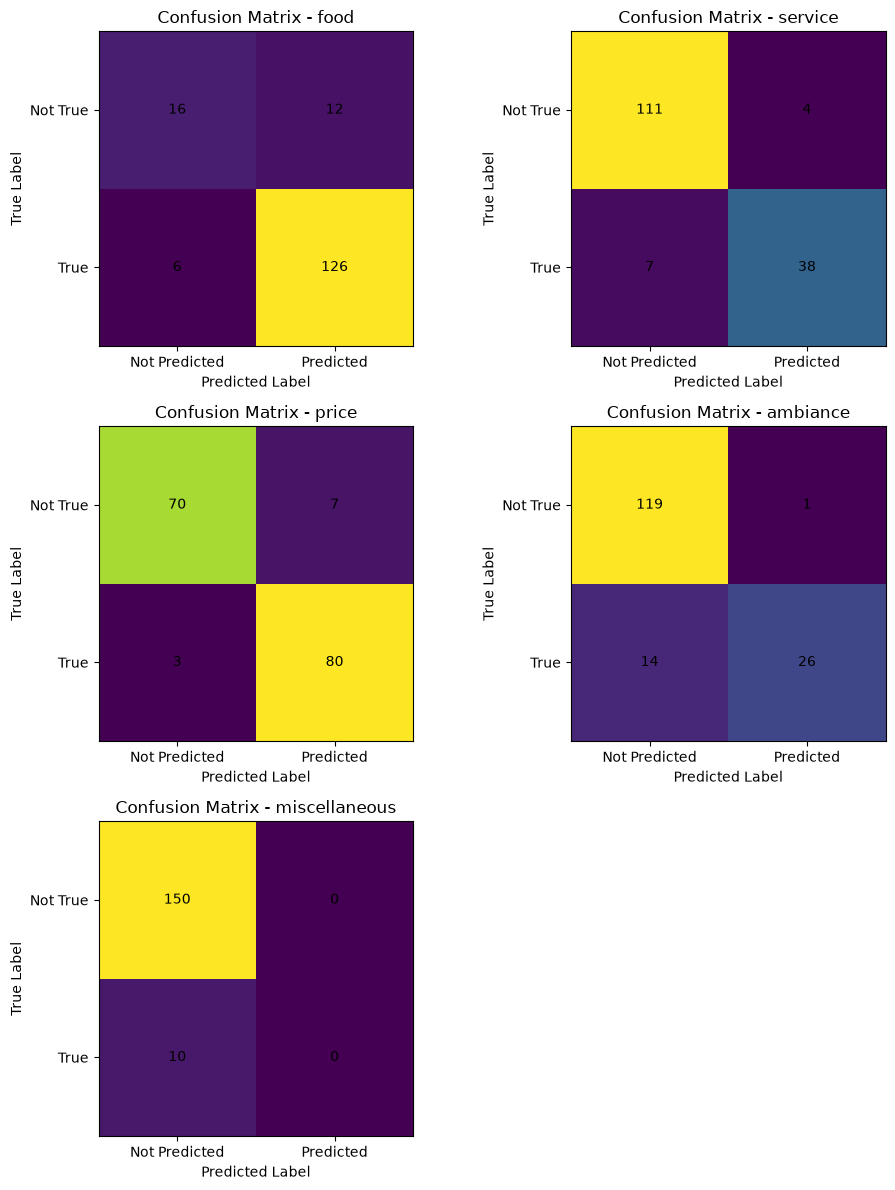

In [15]:
mcm = multilabel_confusion_matrix(y_test, y_test_pred_opt)

plt.figure(figsize=(10, 12))

for i, aspect in enumerate(aspect_cols):
    plt.subplot(3, 2, i + 1)

    if HAS_SEABORN:
        sns.heatmap(
            mcm[i],
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Not Predicted', 'Predicted'],
            yticklabels=['Not True', 'True']
        )
    else:
        plt.imshow(mcm[i])
        for r in range(2):
            for c in range(2):
                plt.text(c, r, str(mcm[i][r, c]), ha='center', va='center')
        plt.xticks([0, 1], ['Not Predicted', 'Predicted'])
        plt.yticks([0, 1], ['Not True', 'True'])

    plt.title(f'Confusion Matrix - {aspect}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')

plt.tight_layout()
plt.show()

## 14. Error analysis

Hiển thị các mẫu model dự đoán sai để phân tích lỗi.

In [16]:
def labels_to_text(row, aspect_cols):
    row = np.asarray(row).astype(bool)
    labels = np.array(aspect_cols)[row]
    return ', '.join(labels) if len(labels) > 0 else 'None'

results_df = pd.DataFrame({
    'review': X_display_test.values,
    'review_cleaned': X_test.values,
    'true_aspects': [labels_to_text(row, aspect_cols) for row in y_test.values],
    'predicted_aspects': [labels_to_text(row, aspect_cols) for row in y_test_pred_opt],
})

for j, aspect in enumerate(aspect_cols):
    results_df[f'prob_{aspect}'] = y_test_prob[:, j].round(3)

misclassified_df = results_df[results_df['true_aspects'] != results_df['predicted_aspects']].copy()

print(f"Total misclassified samples: {len(misclassified_df)} out of {len(results_df)}")
display(misclassified_df.head(10))

Total misclassified samples: 43 out of 160


,review,review_cleaned,true_aspects,predicted_aspects,prob_food,prob_service,prob_price,prob_ambiance,prob_miscellaneous
2,All restaurants need to learn how to cook steak from them and have a very charming atmosphere.,restaurant need learn cook steak charming atmosphere,"food, ambiance",ambiance,0.313,0.370,0.194,0.880,0.219
7,"The ambiance here is great, but the food is a bit expensive.",ambiance great food bit expensive,"price, ambiance","food, price",0.769,0.196,0.701,0.407,0.103
8,"The management of the restaurant knows how to run it well, the food comes as soon as the order is placed.",management restaurant know run well food come soon order placed,service,"food, ambiance",0.616,0.394,0.260,0.574,0.549
11,"Although the restaurant is very old, it has managed to maintain the quality of the food.",although restaurant old managed maintain quality food,"food, ambiance",food,0.837,0.372,0.269,0.363,0.476
13,Orders take slow and the atmosphere feels a bit stuffy.,order take slow atmosphere feel bit stuffy,"service, ambiance","price, ambiance",0.260,0.346,0.432,0.722,0.201
24,"The biryani rice was fluffy, but the meat was tough.",biryani rice fluffy meat tough,food,"food, price",0.922,0.112,0.524,0.144,0.083
27,The taste of the food is unmatched and the surroundings are also very beautiful.,taste food unmatched surroundings also beautiful,"food, ambiance",food,0.920,0.344,0.268,0.441,0.119
33,"The price is right, but this test is different.",price right test different,"price, miscellaneous","food, price",0.770,0.143,0.804,0.178,0.088
35,"Haleem was amazing in one word, I became a fan.",haleem amazing one word became fan,"food, miscellaneous",food,0.805,0.297,0.359,0.302,0.658
38,Every item tasted amazing and their workmanship was better than other places.,every item tasted amazing workmanship better place,"food, service",food,0.612,0.316,0.311,0.548,0.393


## 15. Prediction function for demo

Hàm `predict_aspects()` có thể được đồng đội dùng lại khi phát triển demo.

In [17]:
def predict_aspects(reviews, vectorizer, model, thresholds, aspect_cols, top_k=2, remove_misc=True):
    """
    Predict aspects for new restaurant reviews.

    Parameters
    ----------
    reviews : list[str]
        New review texts. These should be in the same language/style as training input.
    vectorizer : fitted TfidfVectorizer
    model : trained OneVsRestClassifier(LogisticRegression)
    thresholds : dict
    aspect_cols : list[str]

    Returns
    -------
    pd.DataFrame
        Prediction results with aspects and probabilities.
    """
    reviews = [str(review) for review in reviews]
    X_new_tfidf = vectorizer.transform(reviews)
    y_new_prob = model.predict_proba(X_new_tfidf)

    y_new_pred = apply_thresholds_advanced(
        y_new_prob,
        thresholds,
        aspect_cols,
        top_k=top_k,
        remove_misc=remove_misc
    )

    rows = []
    for i, review in enumerate(reviews):
        row = {
            'review': review,
            'predicted_aspects': labels_to_text(y_new_pred[i], aspect_cols)
        }

        for j, aspect in enumerate(aspect_cols):
            row[f'prob_{aspect}'] = round(float(y_new_prob[i, j]), 3)

        rows.append(row)

    return pd.DataFrame(rows)

## 16. Demo prediction on new reviews

In [18]:
new_reviews = [
    "The food is delicious but the service is slow.",
    "Great ambiance and reasonable prices.",
    "The restaurant is too expensive for the quality of the food.",
    "I will come again."
]

demo_results = predict_aspects(
    new_reviews,
    vectorizer,
    model_aspect,
    thresholds,
    aspect_cols,
    top_k=2,
    remove_misc=True
)

display(demo_results)

,review,predicted_aspects,prob_food,prob_service,prob_price,prob_ambiance,prob_miscellaneous
0,The food is delicious but the service is slow.,"food, service",0.551,0.930,0.192,0.172,0.242
1,Great ambiance and reasonable prices.,"food, ambiance",0.768,0.194,0.479,0.601,0.143
2,The restaurant is too expensive for the quality of the food.,"food, price",0.590,0.197,0.770,0.332,0.441
3,I will come again.,"food, price",0.705,0.388,0.412,0.438,0.146


## 17. Save model artifacts

Các file này dùng để đồng đội tích hợp vào demo mà không cần train lại notebook.

In [19]:

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(vectorizer, os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"))
joblib.dump(model_aspect, os.path.join(MODEL_DIR, "tfidf_logistic_regression_model.pkl"))
joblib.dump(thresholds, os.path.join(MODEL_DIR, "tfidf_thresholds.pkl"))
joblib.dump(aspect_cols, os.path.join(MODEL_DIR, "aspect_cols.pkl"))

print("Saved artifacts:")
print(os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"))
print(os.path.join(MODEL_DIR, "tfidf_logistic_regression_model.pkl"))
print(os.path.join(MODEL_DIR, "tfidf_thresholds.pkl"))
print(os.path.join(MODEL_DIR, "aspect_cols.pkl"))

Saved artifacts:
models\tfidf_vectorizer.pkl
models\tfidf_logistic_regression_model.pkl
models\tfidf_thresholds.pkl
models\aspect_cols.pkl


## 18. Load saved artifacts and test again

Cell này kiểm tra rằng các file đã lưu có thể được load lại để phục vụ demo.

In [20]:

loaded_vectorizer = joblib.load(os.path.join(MODEL_DIR, "tfidf_vectorizer.pkl"))
loaded_model = joblib.load(os.path.join(MODEL_DIR, "tfidf_logistic_regression_model.pkl"))
loaded_thresholds = joblib.load(os.path.join(MODEL_DIR, "tfidf_thresholds.pkl"))
loaded_aspect_cols = joblib.load(os.path.join(MODEL_DIR, "aspect_cols.pkl"))

loaded_demo_results = predict_aspects(
    ["The food was good, but the price was high."],
    loaded_vectorizer,
    loaded_model,
    loaded_thresholds,
    loaded_aspect_cols,
    top_k=2,
    remove_misc=True
)

display(loaded_demo_results)

,review,predicted_aspects,prob_food,prob_service,prob_price,prob_ambiance,prob_miscellaneous
0,"The food was good, but the price was high.","food, price",0.855,0.065,0.985,0.032,0.111
